### 2025 T3 Lab 2 Specification
### Author: SongyuQi
### ZID: z5536858

Image 1: Found 4687 keypoints.
Image 2: Found 4354 keypoints.


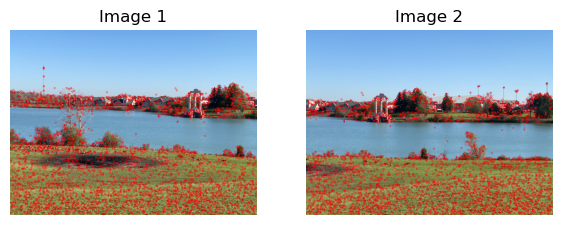

In [28]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt


image_folder = './COMP9517_25T3_Lab2_Images' 
image_files = sorted([f for f in os.listdir(image_folder) if f.endswith(('.jpg'))])

img1_color = cv2.imread(os.path.join(image_folder, image_files[0])) 
img2_color = cv2.imread(os.path.join(image_folder, image_files[1]))

img1_color = cv2.cvtColor(img1_color, cv2.COLOR_BGR2RGB) 
img2_color = cv2.cvtColor(img2_color, cv2.COLOR_BGR2RGB)


img1_gray = cv2.cvtColor(img1_color, cv2.COLOR_RGB2GRAY)
img2_gray = cv2.cvtColor(img2_color, cv2.COLOR_RGB2GRAY)

sift = cv2.SIFT_create()

kp1, _ = sift.detectAndCompute(img1_gray, None)
kp2, _ = sift.detectAndCompute(img2_gray, None)

print(f"Image 1: Found {len(kp1)} keypoints.")
print(f"Image 2: Found {len(kp2)} keypoints.")


img_kp1 = cv2.drawKeypoints(
    img1_color, 
    kp1, 
    None, 
    color=(255, 0, 0), 
    flags=0
)
img_kp2 = cv2.drawKeypoints(
    img2_color, 
    kp2, 
    None, 
    color=(255, 0, 0), 
    flags=0
)


fig, axes = plt.subplots(1, 2, figsize=(7, 7))
axes[0].imshow(img_kp1)
axes[0].set_title(f'Image 1')
axes[0].axis('off')

axes[1].imshow(img_kp2)
axes[1].set_title(f'Image 2')
axes[1].axis('off')

plt.show()

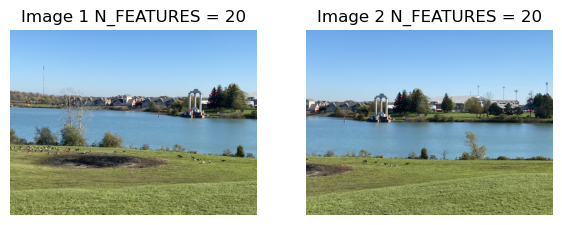

In [29]:
N_FEATURES = 20

sift_nfeat = cv2.SIFT_create(nfeatures=N_FEATURES)

kp1_nfeat, _ = sift_nfeat.detectAndCompute(img1_gray, None)
kp2_nfeat, _ = sift_nfeat.detectAndCompute(img2_gray, None)

img_kp1_nfeat = cv2.drawKeypoints(
    img1_color, 
    kp1_nfeat, 
    None, 
    color=(255, 0, 0), 
    flags=0
)
img_kp2_nfeat = cv2.drawKeypoints(
    img2_color, 
    kp2_nfeat, 
    None, 
    color=(255, 0, 0),
    flags=0
)

fig, axes = plt.subplots(1, 2, figsize=(7, 7))
axes[0].imshow(img_kp1_nfeat)
axes[0].set_title(f'Image 1 N_FEATURES = 20')
axes[0].axis('off')

axes[1].imshow(img_kp2_nfeat)
axes[1].set_title(f'Image 2 N_FEATURES = 20')
axes[1].axis('off')
plt.show()

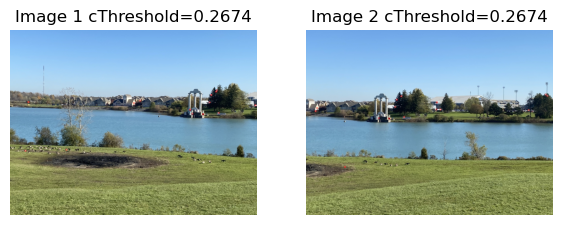

Image 1 (cThreshold=0.2674): Found 20 keypoints.
Image 2 (cThreshold=0.2674): Found 21 keypoints.


In [30]:
CONTRAST_THRESHOLD = 0.2674

sift_cthresh = cv2.SIFT_create(contrastThreshold=CONTRAST_THRESHOLD)

kp1_cthresh, _ = sift_cthresh.detectAndCompute(img1_gray, None)
kp2_cthresh, _ = sift_cthresh.detectAndCompute(img2_gray, None)

img_kp1_cthresh = cv2.drawKeypoints(
    img1_color, 
    kp1_cthresh, 
    None, 
    color=(255, 0, 0), 
    flags=0
)
img_kp2_cthresh = cv2.drawKeypoints(
    img2_color, 
    kp2_cthresh, 
    None, 
    color=(255, 0, 0),
    flags=0
)

fig, axes = plt.subplots(1, 2, figsize=(7, 7))
axes[0].imshow(img_kp1_cthresh)
axes[0].set_title(f'Image 1 cThreshold={CONTRAST_THRESHOLD}')
axes[0].axis('off')

axes[1].imshow(img_kp2_cthresh)
axes[1].set_title(f'Image 2 cThreshold={CONTRAST_THRESHOLD}')
axes[1].axis('off')

plt.show()

print(f"Image 1 (cThreshold={CONTRAST_THRESHOLD}): Found {len(kp1_cthresh)} keypoints.")
print(f"Image 2 (cThreshold={CONTRAST_THRESHOLD}): Found {len(kp2_cthresh)} keypoints.")

## In Tast1 b) I've used **two approaches**.

### Approach1:
Set the **nfeature = 20**, the SIFT frame give me most prominent 20 keypoints which sorted inside automaticly.

### Approach2:
Set the **contrastThreshold = 0.2674**, Image1 found 20 keypoints and Image2 found 21 keypoints. The default parameter of contrastThreshold = 0.04. In default parameters the keypoints(almost) = 4500. So I try the first contrastThreshold = 0.2 and add the parameter step by step = 0.01.

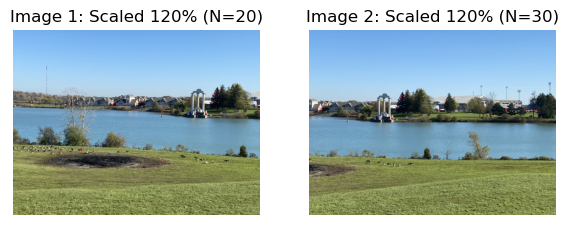

In [31]:
scale_factor = 1.2

img1_scaled_color = cv2.resize(img1_color, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_CUBIC)
img2_scaled_color = cv2.resize(img2_color, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_CUBIC)

img1_scaled_gray = cv2.cvtColor(img1_scaled_color, cv2.COLOR_RGB2GRAY)
img2_scaled_gray = cv2.cvtColor(img2_scaled_color, cv2.COLOR_RGB2GRAY)

kp1_scaled, _ = sift_cthresh.detectAndCompute(img1_scaled_gray, None)
kp2_scaled, _ = sift_cthresh.detectAndCompute(img2_scaled_gray, None)

img_kp1_scaled = cv2.drawKeypoints(
    img1_scaled_color, 
    kp1_scaled, 
    None, 
    color=(255, 0, 0), 
    flags=0
)
img_kp2_scaled = cv2.drawKeypoints(
    img2_scaled_color, 
    kp2_scaled, 
    None, 
    color=(255, 0, 0),
    flags=0
)

fig, axes = plt.subplots(1, 2, figsize=(7, 7))
axes[0].imshow(img_kp1_scaled)
axes[0].set_title(f'Image 1: Scaled 120% (N={len(kp1_scaled)})')
axes[0].axis('off')

axes[1].imshow(img_kp2_scaled)
axes[1].set_title(f'Image 2: Scaled 120% (N={len(kp2_scaled)})')
axes[1].axis('off')
plt.show()

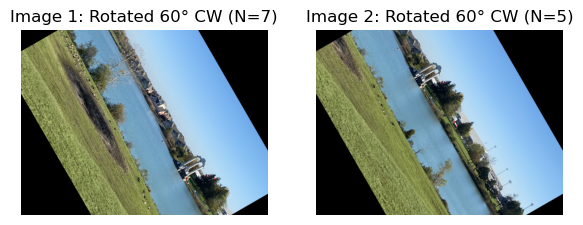

In [32]:
angle = -60 

def rotate_image(img, angle):
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h))
    return rotated

img1_rotated_color = rotate_image(img1_color, angle)
img2_rotated_color = rotate_image(img2_color, angle)

img1_rotated_gray = cv2.cvtColor(img1_rotated_color, cv2.COLOR_RGB2GRAY)
img2_rotated_gray = cv2.cvtColor(img2_rotated_color, cv2.COLOR_RGB2GRAY)

kp1_rotated, _ = sift_cthresh.detectAndCompute(img1_rotated_gray, None)
kp2_rotated, _ = sift_cthresh.detectAndCompute(img2_rotated_gray, None)

img_kp1_rotated = cv2.drawKeypoints(
    img1_rotated_color, 
    kp1_rotated, 
    None, 
    color=(255, 0, 0), 
    flags=0
)
img_kp2_rotated = cv2.drawKeypoints(
    img2_rotated_color, 
    kp2_rotated, 
    None, 
    color=(255, 0, 0),
    flags=0
)

fig, axes = plt.subplots(1, 2, figsize=(7, 7))
axes[0].imshow(img_kp1_rotated)
axes[0].set_title(f'Image 1: Rotated 60° CW (N={len(kp1_rotated)})')
axes[0].axis('off')

axes[1].imshow(img_kp2_rotated)
axes[1].set_title(f'Image 2: Rotated 60° CW (N={len(kp2_rotated)})')
axes[1].axis('off')
plt.show()

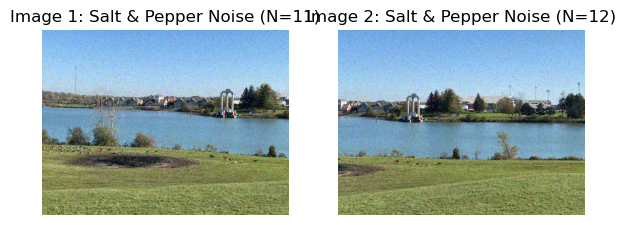


--- Task 2: Summary ---

Original Keypoint Count (contrastThreshold=0.2674): 
Image 1: 20
Image 2: 21

Processed Keypoint Counts:
a) Scaled (120%): Image 1 (20), Image 2 (30)
b) Rotated (60° CW): Image 1 (7), Image 2 (5)
c) Salt & Pepper Noise: Image 1 (11), Image 2 (12)



In [33]:
import skimage.util
from skimage.util import random_noise

img1_float = img1_color / 255.0
img2_float = img2_color / 255.0

noise_amount = 0.05
img1_noise_float = random_noise(img1_float, mode='s&p', amount=noise_amount)
img2_noise_float = random_noise(img2_float, mode='s&p', amount=noise_amount)

img1_noise_color = (img1_noise_float * 255).astype(np.uint8)
img2_noise_color = (img2_noise_float * 255).astype(np.uint8)

img1_noise_gray = cv2.cvtColor(img1_noise_color, cv2.COLOR_RGB2GRAY)
img2_noise_gray = cv2.cvtColor(img2_noise_color, cv2.COLOR_RGB2GRAY)

kp1_noise, _ = sift_cthresh.detectAndCompute(img1_noise_gray, None)
kp2_noise, _ = sift_cthresh.detectAndCompute(img2_noise_gray, None)

img_kp1_noise = cv2.drawKeypoints(
    img1_noise_color, 
    kp1_noise, 
    None, 
    color=(255, 0, 0), 
    flags=0
)
img_kp2_noise = cv2.drawKeypoints(
    img2_noise_color, 
    kp2_noise, 
    None, 
    color=(255, 0, 0),
    flags=0
)

fig, axes = plt.subplots(1, 2, figsize=(7, 7))
axes[0].imshow(img_kp1_noise)
axes[0].set_title(f'Image 1: Salt & Pepper Noise (N={len(kp1_noise)})')
axes[0].axis('off')

axes[1].imshow(img_kp2_noise)
axes[1].set_title(f'Image 2: Salt & Pepper Noise (N={len(kp2_noise)})')
axes[1].axis('off')
plt.show()


print(f"""
--- Task 2: Summary ---

Original Keypoint Count (contrastThreshold=0.2674): 
Image 1: {len(kp1_cthresh)}
Image 2: {len(kp2_cthresh)}

Processed Keypoint Counts:
a) Scaled (120%): Image 1 ({len(kp1_scaled)}), Image 2 ({len(kp2_scaled)})
b) Rotated (60° CW): Image 1 ({len(kp1_rotated)}), Image 2 ({len(kp2_rotated)})
c) Salt & Pepper Noise: Image 1 ({len(kp1_noise)}), Image 2 ({len(kp2_noise)})
""")

1. Are the keypoints of the processed pictures roughly the same as those of the originals?
- **Yes:** **Scaled** and **Rotated**'s keypoints can be found roughly the same as those of the originals.
- **No:** The "Noise"'s keypoints are differant of the originals.

2. What does this say about the robustness of SIFT in each case?
- **Scaling:** Have high robustness because of the SIFT's Scale-invariant.
- **Rotation:** Have high robustness because of the SIFT's Rotation-invariant.
- **Salt & Pepper Noise:** Not robust. Because the calculate of SIFT need smooth and gradient. The noise destroy the originals datas.


3. To which of the three types of processing is SIFT most robust?
- I think the **Scaled** is SIFT most robust in this task. Because the number of keypoints and the keypoints also simillar of the originals. But in theoratical the **Rotation** is SIFT most robust. Because the vector data of originals and after rotation's are totally simillar. The scaled have some differant.

Keypoints: 4687 and 4354
Good matches: 951


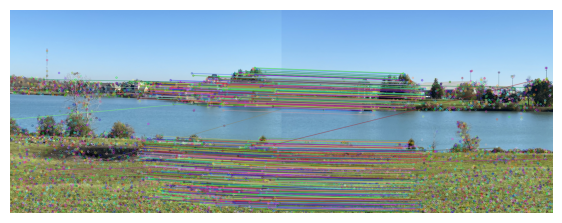

In [34]:
sift_match = cv2.SIFT_create() 

kp1_match, des1_match = sift_match.detectAndCompute(img1_gray, None)
kp2_match, des2_match = sift_match.detectAndCompute(img2_gray, None)

print(f"Keypoints: {len(kp1_match)} and {len(kp2_match)}")

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

matches = bf.knnMatch(des1_match, des2_match, k=2)

ratio_threshold = 0.75 

good_matches = []
for match in matches:
    if len(match) == 2:
        m, n = match
        if m.distance < ratio_threshold * n.distance:
            good_matches.append(m)
    
print(f"Good matches: {len(good_matches)}")

img_matches = cv2.drawMatches(
    img1_color, 
    kp1_match, 
    img2_color, 
    kp2_match, 
    good_matches, 
    None, 
    flags=0
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img_matches)
ax.axis('off')
plt.show()

Task 3b: Found 799 inlier matches after RANSAC.


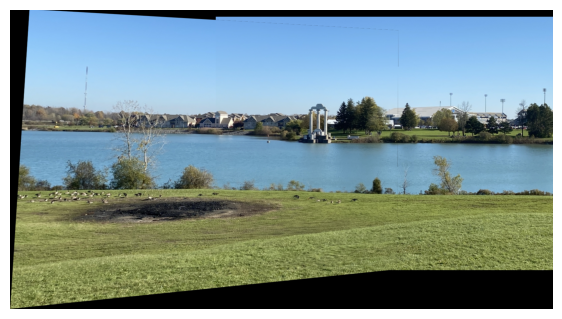

In [35]:
src_pts = np.float32([ kp1_match[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
dst_pts = np.float32([ kp2_match[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
matchesMask_list = mask.ravel().tolist() 

inlier_matches = [good_matches[i] for i, m in enumerate(mask) if m[0] == 1]
print(f"Task 3b: Found {len(inlier_matches)} inlier matches after RANSAC.")

h1, w1 = img1_color.shape[:2]
h2, w2 = img2_color.shape[:2]

corners1 = np.float32([[0, 0], [w1, 0], [w1, h1], [0, h1]]).reshape(-1, 1, 2)
corners2 = np.float32([[0, 0], [w2, 0], [w2, h2], [0, h2]]).reshape(-1, 1, 2)

corners1_warp = cv2.perspectiveTransform(corners1, H)

all_x = np.concatenate([corners1_warp[:, 0, 0], corners2[:, 0, 0]])
all_y = np.concatenate([corners1_warp[:, 0, 1], corners2[:, 0, 1]])

min_x, min_y = np.floor([all_x.min(), all_y.min()]).astype(int)
max_x, max_y = np.ceil([all_x.max(), all_y.max()]).astype(int)

Tx, Ty = -min_x if min_x < 0 else 0, -min_y if min_y < 0 else 0
T = np.array([[1.0, 0.0, Tx],
              [0.0, 1.0, Ty],
              [0.0, 0.0, 1.0]], dtype=np.float32)

out_w = int(max_x - min_x)
out_h = int(max_y - min_y)

img1_warped = cv2.warpPerspective(img1_color, T @ H, (out_w, out_h))
img2_warped = cv2.warpPerspective(img2_color, T, (out_w, out_h))

pano = np.zeros((out_h, out_w, 3), dtype=np.uint8)
mask1 = np.any(img1_warped > 0, axis=2)
mask2 = np.any(img2_warped > 0, axis=2)

only1 = mask1 & (~mask2)
only2 = mask2 & (~mask1)
pano[only1] = img1_warped[only1]
pano[only2] = img2_warped[only2]

overlap = mask1 & mask2
alpha = 0.27
pano[overlap] = (alpha * img1_warped[overlap] + (1.0 - alpha) * img2_warped[overlap]).astype(np.uint8)

pano_cropped = pano

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(pano_cropped)
ax.axis('off')
plt.show()

Keypoints: 4823 and 4107
Good matches: 1741


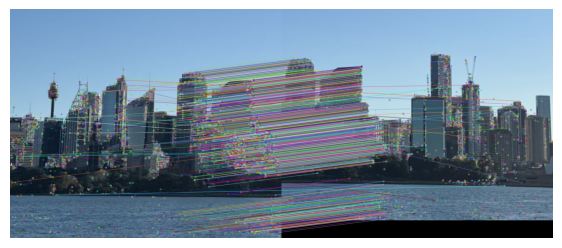

Task 3b: Found 1690 inlier matches after RANSAC.


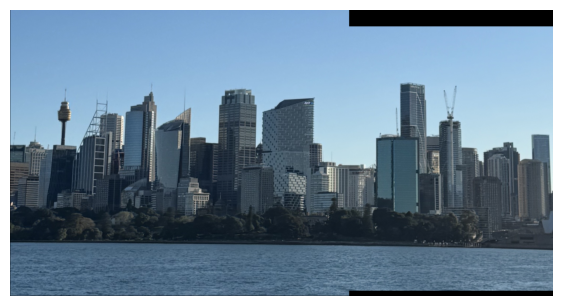

In [36]:
img1_color = cv2.imread(os.path.join('mypic1.jpg')) 
img2_color = cv2.imread(os.path.join('mypic2.jpg'))

img1_color = cv2.cvtColor(img1_color, cv2.COLOR_BGR2RGB) 
img2_color = cv2.cvtColor(img2_color, cv2.COLOR_BGR2RGB)


img1_gray = cv2.cvtColor(img1_color, cv2.COLOR_RGB2GRAY)
img2_gray = cv2.cvtColor(img2_color, cv2.COLOR_RGB2GRAY)

sift_match = cv2.SIFT_create() 

kp1_match, des1_match = sift_match.detectAndCompute(img1_gray, None)
kp2_match, des2_match = sift_match.detectAndCompute(img2_gray, None)

print(f"Keypoints: {len(kp1_match)} and {len(kp2_match)}")

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)

matches = bf.knnMatch(des1_match, des2_match, k=2)

ratio_threshold = 0.75 

good_matches = []
for match in matches:
    if len(match) == 2:
        m, n = match
        if m.distance < ratio_threshold * n.distance:
            good_matches.append(m)
    
print(f"Good matches: {len(good_matches)}")

img_matches = cv2.drawMatches(
    img1_color, 
    kp1_match, 
    img2_color, 
    kp2_match, 
    good_matches, 
    None, 
    flags=0
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img_matches)
ax.axis('off')
plt.show()

src_pts = np.float32([ kp1_match[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
dst_pts = np.float32([ kp2_match[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
matchesMask_list = mask.ravel().tolist() 

inlier_matches = [good_matches[i] for i, m in enumerate(mask) if m[0] == 1]
print(f"Task 3b: Found {len(inlier_matches)} inlier matches after RANSAC.")

h1, w1 = img1_color.shape[:2]
h2, w2 = img2_color.shape[:2]

corners1 = np.float32([[0, 0], [w1, 0], [w1, h1], [0, h1]]).reshape(-1, 1, 2)
corners2 = np.float32([[0, 0], [w2, 0], [w2, h2], [0, h2]]).reshape(-1, 1, 2)

corners1_warp = cv2.perspectiveTransform(corners1, H)

all_x = np.concatenate([corners1_warp[:, 0, 0], corners2[:, 0, 0]])
all_y = np.concatenate([corners1_warp[:, 0, 1], corners2[:, 0, 1]])

min_x, min_y = np.floor([all_x.min(), all_y.min()]).astype(int)
max_x, max_y = np.ceil([all_x.max(), all_y.max()]).astype(int)

Tx, Ty = -min_x if min_x < 0 else 0, -min_y if min_y < 0 else 0
T = np.array([[1.0, 0.0, Tx],
              [0.0, 1.0, Ty],
              [0.0, 0.0, 1.0]], dtype=np.float32)

out_w = int(max_x - min_x)
out_h = int(max_y - min_y)

img1_warped = cv2.warpPerspective(img1_color, T @ H, (out_w, out_h))
img2_warped = cv2.warpPerspective(img2_color, T, (out_w, out_h))

pano = np.zeros((out_h, out_w, 3), dtype=np.uint8)
mask1 = np.any(img1_warped > 0, axis=2)
mask2 = np.any(img2_warped > 0, axis=2)

only1 = mask1 & (~mask2)
only2 = mask2 & (~mask1)
pano[only1] = img1_warped[only1]
pano[only2] = img2_warped[only2]

overlap = mask1 & mask2
alpha = 0.27
pano[overlap] = (alpha * img1_warped[overlap] + (1.0 - alpha) * img2_warped[overlap]).astype(np.uint8)

pano_cropped = pano

fig, ax = plt.subplots(figsize=(7,7))
ax.imshow(pano_cropped)
ax.axis('off')
plt.show()